# Ensemble model -- can combining predictors beat AlphaMissense alone?

Trains a logistic regression on AlphaMissense + PolyPhen + CADD.
Uses stratified cross-validation to avoid leakage on the small dataset (286 variants).
Compares ensemble AUC and AP against AlphaMissense alone.

Requires `../data/cftr2_results_annotated.csv` from `alphamissense.ipynb` and CADD/PolyPhen/SIFT scores from `comparison.ipynb`.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

## Step 1. Load labelled variants with all four scores

In [2]:
result = pd.read_csv("../data/cftr2_results_annotated.csv")

binary = result[
    result["determination_2026"].isin(["CF-causing", "Non CF-causing"]) &
    result["am_pathogenicity"].notna()
].copy()
binary["label"] = (binary["determination_2026"] == "CF-causing").astype(int)

print(f"Labelled variants: {len(binary)}")
print(f"CF-causing    : {binary['label'].sum()}")
print(f"Non CF-causing: {(binary['label'] == 0).sum()}")

Labelled variants: 292
CF-causing    : 253
Non CF-causing: 39


## Step 2. Extract CADD, SIFT, PolyPhen from VCF

In [3]:
import requests, time

protein_pattern = re.compile(r'p\.([A-Z][a-z]{2}\d+[A-Z][a-z]{2})')
csq_pattern = re.compile(r'CSQ=([^;]+)')
SIFT_INDEX = 31
POLYPHEN_INDEX = 32

variant_coords = {}
variant_scores = {}

with open("../data/All_Variants_VEP.Gene.vcf", encoding="utf-8", errors="replace") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        parts = line.strip().split("\t")
        if len(parts) < 5:
            continue
        chrom, pos, _, ref, alt = parts[0], parts[1], parts[2], parts[3], parts[4]
        prot_match = protein_pattern.search(line)
        if prot_match:
            name = prot_match.group(1)
            if name not in variant_coords:
                variant_coords[name] = {"chrom": chrom, "pos": pos, "ref": ref, "alt": alt}
        csq_match = csq_pattern.search(line)
        if csq_match:
            for transcript in csq_match.group(1).split(","):
                fields = transcript.split("|")
                if len(fields) <= POLYPHEN_INDEX:
                    continue
                pm = protein_pattern.search(fields[11])
                if not pm:
                    continue
                n = pm.group(1)
                sift = fields[SIFT_INDEX]
                polyphen = fields[POLYPHEN_INDEX]
                if n not in variant_scores and sift and polyphen:
                    variant_scores[n] = {"sift": sift, "polyphen": polyphen}

def parse_sift(s):
    m = re.search(r'\(([0-9.]+)\)', s)
    return 1 - float(m.group(1)) if m else None

def parse_polyphen(s):
    m = re.search(r'\(([0-9.]+)\)', s)
    return float(m.group(1)) if m else None

binary["chrom"] = binary["variant"].map({k: v["chrom"] for k, v in variant_coords.items()})
binary["pos"]   = binary["variant"].map({k: v["pos"]   for k, v in variant_coords.items()})
binary["ref"]   = binary["variant"].map({k: v["ref"]   for k, v in variant_coords.items()})
binary["alt"]   = binary["variant"].map({k: v["alt"]   for k, v in variant_coords.items()})
binary["sift_score"]    = binary["variant"].map({k: parse_sift(v["sift"]) for k, v in variant_scores.items()})
binary["polyphen_score"] = binary["variant"].map({k: parse_polyphen(v["polyphen"]) for k, v in variant_scores.items()})

print(f"Coordinates found   : {binary['pos'].notna().sum()}")
print(f"PolyPhen scores     : {binary['polyphen_score'].notna().sum()}")
print(f"SIFT scores         : {binary['sift_score'].notna().sum()}")

Coordinates found   : 292
PolyPhen scores     : 290
SIFT scores         : 290


## Step 3. Fetch CADD scores

In [5]:
CADD_URL = "https://cadd.gs.washington.edu/api/v1.0/GRCh38-v1.7/{chrom}:{pos}_{ref}_{alt}"

def get_cadd_score(chrom, pos, ref, alt):
    try:
        url = CADD_URL.format(chrom=chrom, pos=pos, ref=ref, alt=alt)
        resp = requests.get(url, timeout=10)
        data = resp.json()
        if data and len(data) > 0:
            return float(data[0]["PHRED"])
        return None
    except Exception:
        return None

cadd_scores = []
for i, row in binary.iterrows():
    score = get_cadd_score(row["chrom"], row["pos"], row["ref"], row["alt"])
    cadd_scores.append(score)
    if len(cadd_scores) % 20 == 0:
        print(f"  {len(cadd_scores)} / {len(binary)} done")
    time.sleep(0.3)

binary["cadd_score"] = cadd_scores
print(f"\nCADD scored: {binary['cadd_score'].notna().sum()} / {len(binary)}")

  20 / 292 done
  40 / 292 done
  60 / 292 done
  80 / 292 done
  100 / 292 done
  120 / 292 done
  140 / 292 done
  160 / 292 done
  180 / 292 done
  200 / 292 done
  220 / 292 done
  240 / 292 done
  260 / 292 done
  280 / 292 done

CADD scored: 286 / 292


## Step 4. Ensemble -- logistic regression with cross-validation

286 samples is too small to hold out a test set. We use stratified 5-fold cross-validation.
Scores from each fold are concatenated to produce out-of-fold predictions for the full dataset.
This gives an unbiased estimate of ensemble performance.

In [6]:
compare = binary[
    binary["cadd_score"].notna() &
    binary["sift_score"].notna() &
    binary["polyphen_score"].notna()
].copy()

print(f"Variants with all scores: {len(compare)}")

features = ["am_pathogenicity", "polyphen_score", "cadd_score"]
X = compare[features].values
y = compare["label"].values

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ensemble_probs = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]

ensemble_auc = roc_auc_score(y, ensemble_probs)
ensemble_ap  = average_precision_score(y, ensemble_probs)
am_auc       = roc_auc_score(y, compare["am_pathogenicity"])
am_ap        = average_precision_score(y, compare["am_pathogenicity"])

print(f"\nAlphaMissense alone  AUC: {am_auc:.3f} | AP: {am_ap:.3f}")
print(f"Ensemble             AUC: {ensemble_auc:.3f} | AP: {ensemble_ap:.3f}")

Variants with all scores: 286

AlphaMissense alone  AUC: 0.946 | AP: 0.990
Ensemble             AUC: 0.927 | AP: 0.983


## Step 5. ROC and PR curves -- ensemble vs AlphaMissense

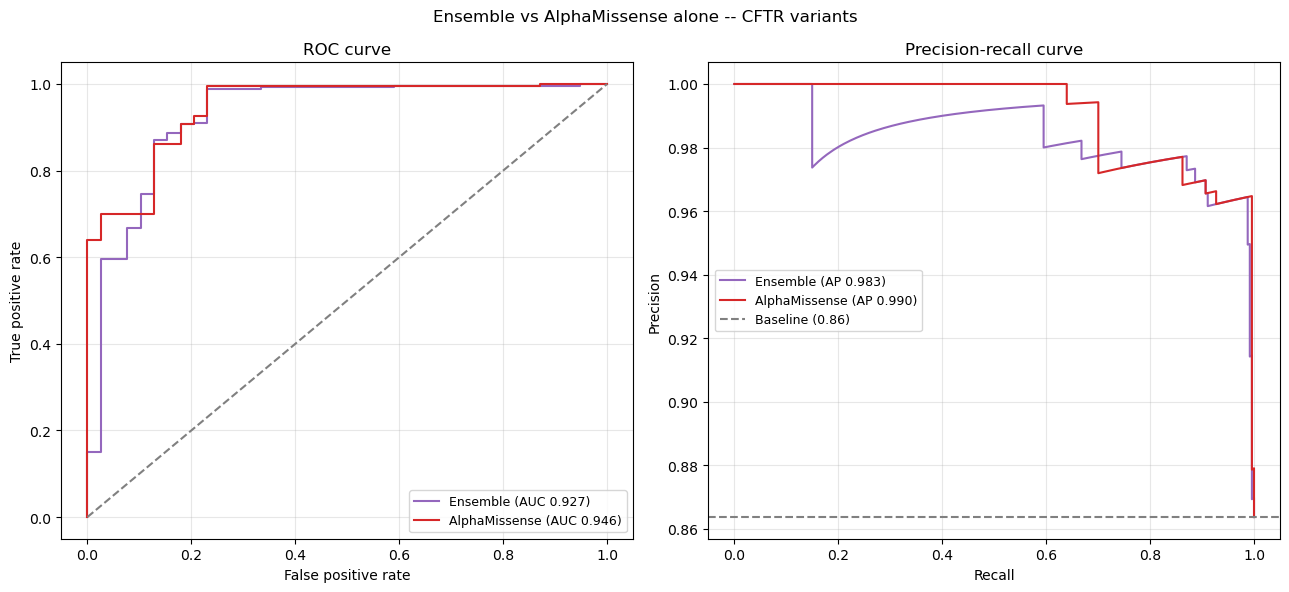

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

# ROC
for name, scores, color in [
    ("Ensemble", ensemble_probs, "#9467bd"),
    ("AlphaMissense", compare["am_pathogenicity"], "#d62728"),
]:
    fpr, tpr, _ = roc_curve(y, scores)
    auc = roc_auc_score(y, scores)
    ax1.plot(fpr, tpr, color=color, label=f"{name} (AUC {auc:.3f})")
ax1.plot([0,1],[0,1], linestyle="--", color="grey")
ax1.set_xlabel("False positive rate")
ax1.set_ylabel("True positive rate")
ax1.set_title("ROC curve")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# PR
for name, scores, color in [
    ("Ensemble", ensemble_probs, "#9467bd"),
    ("AlphaMissense", compare["am_pathogenicity"], "#d62728"),
]:
    precision, recall, _ = precision_recall_curve(y, scores)
    ap = average_precision_score(y, scores)
    ax2.plot(recall, precision, color=color, label=f"{name} (AP {ap:.3f})")
baseline = y.mean()
ax2.axhline(baseline, linestyle="--", color="grey", label=f"Baseline ({baseline:.2f})")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-recall curve")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle("Ensemble vs AlphaMissense alone -- CFTR variants", fontsize=12)
plt.tight_layout()
plt.savefig("../figures/ensemble_vs_am.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 6. Feature weights -- what does the model rely on?

In [8]:
pipe.fit(X, y)
coefs = pipe.named_steps["clf"].coef_[0]

print("Feature weights (after scaling):")
for feat, coef in sorted(zip(features, coefs), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:25} {coef:+.3f}")

Feature weights (after scaling):
  am_pathogenicity          +1.907
  cadd_score                +0.279
  polyphen_score            -0.117


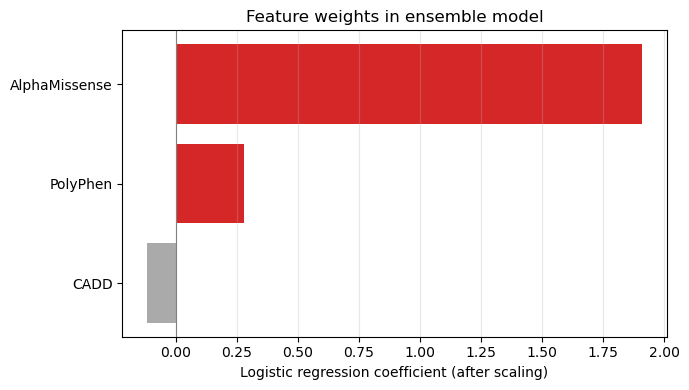

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

coef_df = pd.DataFrame({
    "feature": ["AlphaMissense", "CADD", "PolyPhen"],
    "weight": coefs
}).sort_values("weight", ascending=True)

colors = ["#d62728" if w > 0 else "#aaaaaa" for w in coef_df["weight"]]
ax.barh(coef_df["feature"], coef_df["weight"], color=colors)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_xlabel("Logistic regression coefficient (after scaling)")
ax.set_title("Feature weights in ensemble model")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("../figures/ensemble_weights.png", dpi=150, bbox_inches="tight")
plt.show()

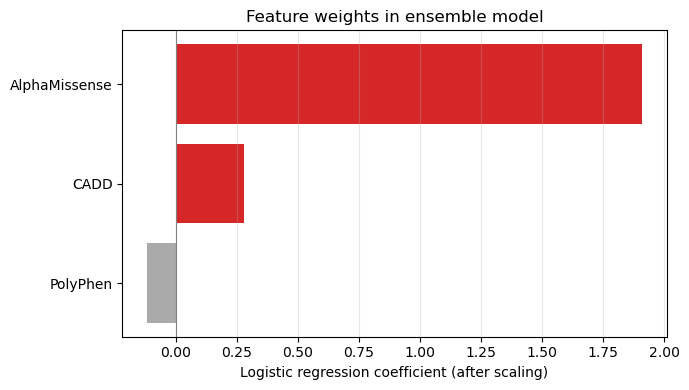

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

coef_df = pd.DataFrame({
    "feature": ["AlphaMissense", "PolyPhen", "CADD"],
    "weight": coefs
}).sort_values("weight", ascending=True)

colors = ["#d62728" if w > 0 else "#aaaaaa" for w in coef_df["weight"]]
ax.barh(coef_df["feature"], coef_df["weight"], color=colors)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_xlabel("Logistic regression coefficient (after scaling)")
ax.set_title("Feature weights in ensemble model")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("../figures/ensemble_weights.png", dpi=150, bbox_inches="tight")
plt.show()
